In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [3]:
##ATAC Data general
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)

##ATAC Data without unreliable Data
threshold = -np.log10(0.05)
ATAC_data_removed = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_data_removed.__len__() 

362330

# Archiv: Code that I won't use

In [1]:
#Archiv Datensätze mit 30peaks

#(X) ATAC_seq_IL17f via function

def ATAC_seq_Gene(ATAC_data_removed, gene):

    atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains(fr'\b{gene}\b', case=False, na=False)].copy()

    atac_gene_num = atac_gene.drop(annotation_cols, axis=1)

    X = atac_gene_num.T                 
    X_labels = atac_gene['ImmGenATAC1219.peakID'].values

    return atac_gene, X, X_labels


ATAC_Il17f, X, X_labels = ATAC_seq_Gene(ATAC_data_removed, "Il17f")
ATAC_seq_IL17f

#(Y) RNA_seq_IL17f via function

def Y_Gene(RNA_seq, gene):

    RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == gene].drop("Unnamed: 0", axis=1, errors="ignore").copy()
    
    Y = RNA_seq_Gene.T

    return RNA_seq_Gene, Y


RNA_seq_IL17f, Y = Y_Gene(RNA_seq, "Il17f")
RNA_seq_IL17f

NameError: name 'ATAC_data_removed' is not defined

In [ ]:
RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == "Il17f"].drop("Unnamed: 0", axis=1, errors="ignore").copy()

#Only those peaks that are within 100kB of the GOI
atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains("Il17f", case=False, na=False)].copy()
atac_gene_num = atac_gene.drop(annotation_cols, axis=1)


#Check Correlation of each peak with Gene Expression
correlation_Il17f = []

for peak in atac_gene_num.columns:
    corr = atac_gene_num.loc[peak].corr(RNA_seq_Gene.iloc[0])
    correlation_Il17f.append([peak, corr])

correlation_Il17f

#Choose only Top 5 peaks



KeyError: 'LTHSC.34-.BM'

In [ ]:
#via LinearRegression
linreg = LinearRegression()
linreg.fit(X, Y)

r2 = linreg.score(X_scaled, Y)
print("r^2:", round(r2, 3))

#Cross Validation
scores = cross_val_score(linreg, X_scaled, np.ravel(Y), cv=5, scoring="r2")
print("CV R^2 pro Fold:", scores.round(3))
print("CV scores mean:", round(scores.mean(), 3))


r^2: -0.045
CV R^2 pro Fold: [-2.213730e+02 -5.267890e+02 -8.886000e+00  1.740000e-01 -3.291423e+03]
CV scores mean: -809.659


In [ ]:
#via Ridge
ridgereg = Ridge(alpha=1.0)
ridgereg.fit(X_scaled, Y)

r2 = ridgereg.score(X_scaled, Y)
print("r^2:", r2)

#Cross Validation
scores = cross_val_score(ridgereg, X_scaled, np.ravel(Y), cv=5, scoring="r2")
print("CV R^2 pro Fold:", scores.round(3))
print("CV scores mean:", round(scores.mean(), 3))

r^2: 0.8972795473173509
CV R^2 pro Fold: [-2.16174e+02 -4.78971e+02 -1.50120e+01  1.02000e-01 -2.70894e+03]
CV scores mean: -683.799


In [ ]:
##(Y) RNA_seq_IL17f via function


def Y_Gene(RNA_seq, gene):

    RNA_seq_Gene = RNA_seq[RNA_seq["Unnamed: 0"] == gene].drop("Unnamed: 0", axis=1, errors="ignore").copy()
    
    Y = RNA_seq_Gene.iloc[0]

    return RNA_seq_Gene, Y


RNA_Seq_Gene, Y = Y_Gene(RNA_seq, "Il17f")
RNA_seq_IL17f

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
7817,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.13509,1.017884,1.040295,1.017884,1.021351


In [ ]:
##(X) ATAC_seq_IL17f via function

def ATAC_seq_Gene(ATAC_data_removed, gene, Y):

    atac_gene = ATAC_data_removed[ATAC_data_removed['genes.within.100Kb'].str.contains(fr'\b{gene}\b', case=False, na=False)].copy()

    atac_gene_num = atac_gene.drop(annotation_cols, axis=1)

    X = atac_gene_num.T                 
    X_labels = atac_gene['ImmGenATAC1219.peakID'].values

    common_cells = X.index.intersection(Y.index)
    X = X.loc[common_cells]
    Y = Y.loc[common_cells]

    Y = Y.loc[X.index]

    correlation = []

    for i in X.index:
        corr = X.loc[i].corr(Y)
        correlation.append([i, corr])

    return atac_gene, X, X_labels, correlation


ATAC_Il17f, X, X_labels, correlation = ATAC_seq_Gene(ATAC_data_removed, "Il17f", Y)
correlation

[['LTHSC.34-.BM', nan],
 ['LTHSC.34+.BM', nan],
 ['STHSC.150-.BM', nan],
 ['MPP4.135+.BM', nan],
 ['proB.CLP.BM', nan],
 ['proB.FrA.BM', nan],
 ['proB.FrBC.BM', nan],
 ['B.FrE.BM', nan],
 ['B1b.PC', nan],
 ['B.T1.Sp', nan],
 ['B.T2.Sp', nan],
 ['B.T3.Sp', nan],
 ['B.Sp', nan],
 ['B.Fem.Sp', nan],
 ['B.MZ.Sp', nan],
 ['B.Fo.Sp', nan],
 ['B.mem.Sp', nan],
 ['B.GC.CB.Sp', nan],
 ['B.GC.CC.Sp', nan],
 ['B.PB.Sp', nan],
 ['B.PC.Sp', nan],
 ['B.PC.BM', nan],
 ['preT.DN1.Th', nan],
 ['preT.DN2a.Th', nan],
 ['preT.DN2b.Th', nan],
 ['preT.DN3.Th', nan],
 ['T.DN4.Th', nan],
 ['T.ISP.Th', nan],
 ['T.DP.Th', nan],
 ['T.4.Th', nan],
 ['T.8.Th', nan],
 ['T.4.Nve.Sp', nan],
 ['T.4.Nve.Fem.Sp', nan],
 ['T.8.Nve.Sp', nan],
 ['T.4.Sp.aCD3+CD40.18hr', nan],
 ['Treg.4.FP3+.Nrplo.Co', nan],
 ['Treg.4.25hi.Sp', nan],
 ['T8.TN.P14.Sp', nan],
 ['T8.TE.LCMV.d7.Sp', nan],
 ['T8.MP.LCMV.d7.Sp', nan],
 ['T8.Tcm.LCMV.d180.Sp', nan],
 ['T8.Tem.LCMV.d180.Sp', nan],
 ['NKT.Sp', nan],
 ['NKT.Sp.LPS.3hr', nan],
 ['NKT.

In [ ]:
#Index anpassen
 
common_cells = X.index.intersection(Y.index)
X = X.loc[common_cells]
Y = Y.loc[common_cells]

Y = Y.loc[X.index]

X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-trasnformation

**Ergebnis:** Cross-Validation zeigt uns, dass das Modell nicht funktionieren wird. Problem: Overfitting

# Part 0: Understanding the Dataset

## ATACseq: *ImmGenATAC18_AllOCRsInfo.csv*

ATACseq Data with over 500k entries  
each row (=entry) is a OCR peak. The set tells us how strong the peak is in each of the 89 immune cell types  
The data also includes Metadata for each of those peaks:  

- **chrom**  
Chromosome on which the OCR is located  

- **Summit**  
Genomic coordinate of the "peak summit"  
--> position with the strongest ATACseq signal within the OCR  

- **mm10 cons_score**  
as in "evolutionary conservation score"  
--> functional importance (highest value = 1.00)  

- **-log10_bestPvalue**  
remember: p-value measures likelihood of the result being just background noise (small p-value --> likely not background noise)  

- **included in systematic analysis**  
Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper  

- **TSS**  
name of closest TSS gene

- **genes within 100kb**  
just lists all the genes in that range as str 


In [5]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.info()
df["TSS"].describe()

<class 'pandas.DataFrame'>
RangeIndex: 512595 entries, 0 to 512594
Data columns (total 98 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ImmGenATAC1219.peakID            512595 non-null  str    
 1   chrom                            512595 non-null  str    
 2   Summit                           512595 non-null  int64  
 3   mm10.60way.phastCons_scores      512595 non-null  float64
 4   _-log10_bestPvalue               512595 non-null  float64
 5   Included.in.systematic.analysis  334879 non-null  float64
 6   TSS                              14292 non-null   str    
 7   genes.within.100Kb               427710 non-null  str    
 8   LTHSC.34-.BM                     512595 non-null  float64
 9   LTHSC.34+.BM                     512595 non-null  float64
 10  STHSC.150-.BM                    512595 non-null  float64
 11  MPP4.135+.BM                     512595 non-null  float64
 12  proB.CLP.BM  

count     14292
unique    13269
top        Plec
freq          8
Name: TSS, dtype: object

In [ ]:
df.iloc[:, 8:98].describe()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
count,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,...,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000,512595.000000
mean,3.868438,4.005767,4.001125,4.002324,4.008413,4.007382,4.005830,3.964978,3.978077,3.941829,...,4.011853,3.997303,3.977888,3.999854,3.995355,3.998828,3.987949,3.983416,3.976234,3.996922
std,10.004101,9.986633,9.991892,9.994831,9.772241,9.856476,9.842889,9.797304,9.730293,9.643112,...,9.854836,9.832034,9.807041,9.903564,9.900401,9.808067,9.614775,9.709456,9.715224,9.837748
min,0.410000,0.100000,0.110000,0.110000,0.110000,0.100000,0.110000,0.130000,0.110000,0.140000,...,0.100000,0.100000,0.110000,0.110000,0.110000,0.110000,0.100000,0.110000,0.110000,0.110000
25%,0.410000,0.710000,0.110000,0.110000,0.470000,0.630000,0.820000,0.490000,0.780000,0.600000,...,0.770000,0.540000,0.660000,0.530000,0.520000,0.560000,0.720000,0.570000,0.640000,0.530000
50%,0.410000,1.640000,0.900000,1.580000,1.260000,1.340000,1.300000,1.490000,1.350000,1.390000,...,1.260000,1.390000,1.320000,1.370000,1.360000,1.470000,1.400000,1.540000,1.570000,1.360000
75%,2.360000,3.680000,3.520000,3.490000,3.220000,3.290000,3.030000,2.910000,3.090000,2.830000,...,3.120000,3.000000,2.880000,3.080000,3.230000,2.980000,3.120000,3.180000,3.270000,3.270000
max,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,524.280000,727.420000,...,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000,727.420000


In [ ]:
df["TSS"].unique()[:20]

<StringArray>
[            nan,          'Xkr4',        'Mrpl15',        'Lypla1',
         'Tcea1',       'Atp6v1h',        'Npbwr1',        'Rb1cc1',
       'Fam150a',          'St18',         'Sntg1',          'Rrs1',
        'Adhfe1', '2610203C22Rik', '1700034P13Rik',        'Vcpip1',
          'Sgk3',        'Mcmdc2',         'Snhg6',         'Tcf24']
Length: 20, dtype: str

In [ ]:
print(df["genes.within.100Kb"].describe())

print(df["genes.within.100Kb"].unique()[:20])

df["genes.within.100Kb"].head(100)

count     427710
unique     34258
top        Foxp1
freq         383
Name: genes.within.100Kb, dtype: object
<StringArray>
[                  nan,                'Xkr4',                 'Rp1',
           'Rp1,Sox17',               'Sox17',              'Mrpl15',
       'Mrpl15,Lypla1', 'Mrpl15,Lypla1,Tcea1',        'Lypla1,Tcea1',
               'Tcea1',         'Tcea1,Rgs20',               'Rgs20',
       'Rgs20,Atp6v1h',             'Atp6v1h',               'Oprk1',
              'Npbwr1',              'Rb1cc1',      'Rb1cc1,Fam150a',
             'Fam150a',        'Fam150a,St18']
Length: 20, dtype: str


0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
      ...  
95    Sox17
96    Sox17
97    Sox17
98    Sox17
99    Sox17
Name: genes.within.100Kb, Length: 100, dtype: str

## RNAseq: *mmc2.csv*



In [ ]:
mmc2 = pd.read_csv("../data/mmc2.csv")

In [ ]:
mmc2.head(10)

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
1,0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
2,0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
3,0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
4,0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889
5,0610010F05Rik,75.934142,172.175681,119.156447,174.554003,108.544409,103.441388,105.360141,23.970120,31.495899,...,153.948918,167.601425,54.058811,64.600563,57.436333,10.828411,62.087024,105.157158,62.560192,173.985055
6,0610010K14Rik,149.566205,201.786082,155.028950,160.824830,191.201834,203.789960,245.051378,115.914325,151.297298,...,149.689826,106.588218,114.416008,115.421183,131.767622,77.068295,133.957730,112.840010,142.522379,91.553613
7,0610011F06Rik,93.915285,94.031495,79.327033,82.399863,113.672646,115.516567,78.245609,64.922891,64.583432,...,45.059445,41.436261,14.933852,42.677242,58.551452,64.265602,64.546589,13.001635,49.346182,50.389020
8,0610012G03Rik,139.978638,154.170669,122.703765,132.944413,179.129929,156.216207,164.724274,92.040298,144.877474,...,267.090168,201.781036,92.606014,108.289968,110.955717,173.577576,135.442168,127.445206,130.943231,81.641022
9,0610030E20Rik,200.799343,193.643339,238.761950,156.811006,138.817134,132.647306,155.346999,304.985356,208.107675,...,154.611117,155.355460,284.476608,185.259268,220.419454,113.490796,163.536929,114.330366,100.824511,42.343203


In [ ]:
mmc2.info()

<class 'pandas.DataFrame'>
RangeIndex: 17535 entries, 0 to 17534
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             17535 non-null  str    
 1   LTHSC.34-.BM           17535 non-null  float64
 2   LTHSC.34+.BM           17535 non-null  float64
 3   STHSC.150-.BM          17535 non-null  float64
 4   MPP4.135+.BM           17535 non-null  float64
 5   proB.CLP.BM            17535 non-null  float64
 6   proB.FrA.BM            17535 non-null  float64
 7   proB.FrBC.BM           17535 non-null  float64
 8   B.FrE.BM               17535 non-null  float64
 9   B1b.PC                 17535 non-null  float64
 10  B.T1.Sp                17535 non-null  float64
 11  B.T2.Sp                17535 non-null  float64
 12  B.T3.Sp                17535 non-null  float64
 13  B.Sp                   17535 non-null  float64
 14  B.Fem.Sp               17535 non-null  float64
 15  B.MZ.Sp      

In [ ]:
mmc2[mmc2["Unnamed: 0"].str.contains("Il17", case=False)]

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
7814,Il17a,1.020795,1.021260,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
7815,Il17b,1.020795,1.021260,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
7816,Il17c,1.020795,1.021260,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
7817,Il17f,1.096732,1.021260,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351
7818,Il17ra,471.736290,529.492321,838.296499,920.183376,1122.787787,1482.115255,760.846515,602.405654,881.747332,...,381.776180,412.720616,721.879874,331.134262,668.158057,67.019545,428.245093,19.918419,128.378162,122.566027
7819,Il17rb,1.425085,1.880039,2.413484,5.099102,11.796329,33.719879,1.024462,6.181537,8.443390,...,2.476320,2.940554,1.251082,1.022767,83.185323,1.392994,10.846217,1.040295,1.058326,17.263460
7820,Il17rc,5.857585,3.140428,4.424437,6.605107,9.158892,5.218538,2.791838,1.821243,3.591010,...,2.742614,2.361038,1.525293,1.731995,3.575743,298.923066,7.308614,158.423590,263.958813,56.652122
7821,Il17rd,1.096732,1.021260,1.767932,1.392180,1.186354,1.557165,1.392996,1.390761,3.691222,...,3.966084,2.506987,3.574872,1.681309,1.024462,40.379221,2.548027,75.721537,35.345247,1.009448
7822,Il17re,28.271677,54.895407,60.943603,147.146499,55.996801,21.599612,1.024462,1.025833,2.134394,...,1.025785,1.025785,1.400811,2.253052,5.456034,1.019656,1.919807,1.019107,1.017884,106.297374


In [ ]:
il17a = mmc2[mmc2["Unnamed: 0"] == "Il17a"]

il17a.iloc[:, 1:].T.sort_values(by=il17a.index[0], ascending=False).head(20)

,7814
ILC3.CCR6+.SI,104.836685
ILC3.NKp46-CCR6-.SI,42.175516
NKT.Sp.LPS.3hr,34.636492
Treg.4.FP3+.Nrplo.Co,23.987840
NKT.Sp.LPS.18hr,3.984086
ILC2.SI,3.052874
NK.27+11b+.Sp,2.011743
Tgd.g2+d1.24a+.Th,1.162753
proB.FrA.BM,1.140409
NK.27-11b+.BM,1.035532


## QC metrics: *mmc1.xlsx*

QC metrics for ATAC-seq samples  
Summary of immune cell populations and sequencing QC statistics

Source: Yoshida et. al. cis-Regulatory Atlas of Mouse Immune System  



In [ ]:
mmc1 = pd.read_excel("../data/mmc1.xlsx")
## im terminal: uv add openpyxl

In [ ]:
mmc1.head()

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
4,proB.CLP.BM#1,proB.CLP.BM,Hardy,B,B Cell,Bone Marrow,CD19-IgM-CD43+CD24-CD45R-CD93+CD117+IL7Ra+PI-D...,10000,23578208,7.67,6588564,13.21,0.868


In [ ]:
mmc1.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  181 non-null    str    
 1   CellType                                    181 non-null    str    
 2   ImmGenLab                                   181 non-null    str    
 3   Lineage                                     181 non-null    str    
 4   CellFamily                                  181 non-null    str    
 5   Organ                                       181 non-null    str    
 6   SortingMarkers                              181 non-null    str    
 7   InputCellNumber                             181 non-null    int64  
 8   PF.reads                                    181 non-null    int64  
 9   %chrM.mapped                                181 non-null    float64
 10  Paired.read.after.removin

## Gene annotations (refFlat)

In [8]:
#considering the note on the github --> giving order to the txt file
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'

refFlat = pd.read_csv(gene_annotations_path, sep="\t", names=cols)
# need to tell pandas that the txt is tab seperated 

In [9]:
refFlat.head()

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


## TF motif scores: *ImmGenATAC18_AllTFmotifsInOCRs.txt*

In [ ]:
## do not run this cell! Will crash computer :(
TFmotif = pd.read_csv("../data/ImmGenATAC18_AllTFmotifsInOCRs.txt", sep="\t")
## Columns are not labled, thus all the columns are pressed into one column

In [ ]:
TFmotif.info()

#ENSMUSG00000021359_LINE1_Tcfap2a_D_N1;ENSMUSG00000025927_LINE5_Tcfap2b_D;ENSMUSG00000028640_LINE6_Tcfap2c_D;ENSMUSG00000042477_LINE7_Tcfap2e_D;ENSMUSG00000042596_LINE8_Tcfap2d_I;ENSMUSG00000004661_LINE10_Arid3b_D;ENSMUSG00000019564_LINE13_Arid3a_D_N3;ENSMUSG00000019947_LINE15_Arid5b_D;ENSMUSG00000037447_LINE18_Arid5a_D;ENSMUSG00000066224_LINE24_Arid3c_I;ENSMUSG00000033237_LINE27_Arid2_I;ENSMUSG00000024548_LINE28_Setbp1_D;ENSMUSG00000026491_LINE29_Ahctf1_D;ENSMUSG00000056758_LINE31_Hmga2_D;ENSMUSG00000058318_LINE32_Phf21a_D;ENSMUSG00000071262_LINE33_Zfp957_I;ENSMUSG00000000134_LINE36_Tcfe3_D;ENSMUSG00000000282_LINE38_Mnt_D;ENSMUSG00000001988_LINE41_Npas1_I;ENSMUSG00000005718_LINE44_Tcfap4_D;ENSMUSG00000007805_LINE47_Twist2_D;ENSMUSG00000007872_LINE48_Id3_I;ENSMUSG00000009248_LINE50_Ascl2_D_N2;ENSMUSG00000009471_LINE51_Myod1_D;ENSMUSG00000015522_LINE52_Arnt_D_N2;ENSMUSG00000015709_LINE54_Arnt2_D;ENSMUSG00000017801_LINE55_Mlx_D_N3;ENSMUSG00000019256_LINE58_Ahr_I;ENSMUSG00000019789_LINE59_Hey2_D;ENSMUSG00000019913_LINE60_Sim1_I;ENSMUSG00000020167_LINE64_Tcf3_D_N3;ENSMUSG00000020538_LINE66_Srebf1_D_N2;ENSMUSG00000020644_LINE69_Id2_D;ENSMUSG00000021010_LINE71_Npas3_I;ENSMUSG00000021379_LINE72_Id4_I;ENSMUSG00000021575_LINE74_Ahrr_I;ENSMUSG00000022346_LINE75_Myc_D;ENSMUSG00000022463_LINE76_Srebf2_D;ENSMUSG00000022528_LINE77_Hes1_D;ENSMUSG00000023781_LINE78_Hes7_D;ENSMUSG00000023990_LINE80_Tcfeb_D;ENSMUSG00000025128_LINE82_Bhlhe22_D;ENSMUSG00000025930_LINE83_Msc_D;ENSMUSG00000026077_LINE84_Npas2_D;ENSMUSG00000026459_LINE85_Myog_D;ENSMUSG00000026641_LINE86_Usf1_D;ENSMUSG00000026735_LINE87_Ptf1a_I;ENSMUSG00000027794_LINE89_Sohlh2_D;ENSMUSG00000027967_LINE90_Neurog2_I;ENSMUSG00000028654_LINE92_Mycl1_I;ENSMUSG00000028940_LINE94_Hes2_D;ENSMUSG00000029238_LINE96_Clock_D;ENSMUSG00000029553_LINE98_Tcfec_D_N2;ENSMUSG00000030001_LINE99_Figla_D;ENSMUSG00000030103_LINE100_Bhlhe40_D_N5;ENSMUSG00000030256_LINE106_Bhlhe41_D;ENSMUSG00000030543_LINE107_Mesp2_I;ENSMUSG00000030544_LINE108_Mesp1_I;ENSMUSG00000032228_LINE109_Tcf12_D_N1;ENSMUSG00000032744_LINE111_Heyl_I;ENSMUSG00000034161_LINE113_Scx_I;ENSMUSG00000035158_LINE115_Mitf_D;ENSMUSG00000035923_LINE117_Myf6_D_N1;ENSMUSG00000036816_LINE120_Atoh7_I;ENSMUSG00000037169_LINE121_Mycn_D;ENSMUSG00000037335_LINE123_Hand1_I;ENSMUSG00000037621_LINE124_Atoh8_I;ENSMUSG00000038193_LINE126_Hand2_I;ENSMUSG00000038255_LINE127_Neurod2_I;ENSMUSG00000038342_LINE128_Mlxip_D;ENSMUSG00000038932_LINE129_Tcfl5_D;ENSMUSG00000039830_LINE130_Olig2_I;ENSMUSG00000040289_LINE132_Hey1_I;ENSMUSG00000042745_LINE133_Id1_I;ENSMUSG00000044312_LINE135_Neurog3_I;ENSMUSG00000044597_LINE136_Mycs_I;ENSMUSG00000045493_LINE137_Bhlhe23_I;ENSMUSG00000045591_LINE138_Olig3_D;ENSMUSG00000045680_LINE139_Tcf21_D_N1;ENSMUSG00000045903_LINE141_Npas4_I;ENSMUSG00000046160_LINE142_Olig1_I;ENSMUSG00000046518_LINE143_Ferd3l_I;ENSMUSG00000048001_LINE146_Hes5_D;ENSMUSG00000048540_LINE148_Nhlh2_D;ENSMUSG00000048904_LINE150_Neurog1_D;ENSMUSG00000051251_LINE151_Nhlh1_I;ENSMUSG00000052271_LINE152_Bhlha15_D;ENSMUSG00000053477_LINE153_Tcf4_D;ENSMUSG00000055116_LINE154_Arntl_D;ENSMUSG00000057098_LINE155_Ebf1_D;ENSMUSG00000059436_LINE156_Max_D_N3;ENSMUSG00000062713_LINE160_Sim2_I;ENSMUSG00000068079_LINE162_Tcf15_I;ENSMUSG00000073043_LINE166_Atoh1_D_N2;ENSMUSG00000089674_LINE168_Usf2_D;ENSMUSG00000033943_LINE169_Mga_I;BAE290471_LINE1209_Cebpd_I_N23;ENSMUSG00000003545_LINE172_Fosb_I;ENSMUSG00000003949_LINE173_Hlf_D;ENSMUSG00000015461_LINE174_Atf6b_I;ENSMUSG00000015839_LINE175_Nfe2l2_D;ENSMUSG00000018143_LINE177_Mafk_D;ENSMUSG00000020484_LINE179_Xbp1_D_N1;ENSMUSG00000021250_LINE181_Fos_I;ENSMUSG00000022389_LINE183_Tef_D;ENSMUSG00000023027_LINE185_Atf1_D_N1;ENSMUSG00000024912_LINE189_Fosl1_D;ENSMUSG00000025612_LINE191_Bach1_I;ENSMUSG00000025958_LINE192_Creb1_D;ENSMUSG00000026628_LINE193_Atf3_D_N2;ENSMUSG00000026663_LINE196_Atf6_I;ENSMUSG00000027104_LINE197_Atf2_D;ENSMUSG00000029135_LINE202_Fosl2_D;ENSMUSG00000034271_LINE208_Jdp2_D_N2;ENSMUSG00000034957_LINE212_Cebpa_

# Part 1.2: Intronic vs Intergenic enhancers

### Seperating Intronic and Intergenic enhancers
1) defining promotors using TSS metadata from yoshida
2) defining Intergenic peaks using txStart/End
3) defining Intronic peaks through "Ausschlussverfahren" (as long as we are ignoring Exonic peaks)

In [6]:
#Making an "only-promotor" dataset and an "only-enhancer" dataset based on wheter TSS = NaN
only_promotor = ATAC_data_removed[ATAC_data_removed["TSS"].notna()].copy() 
only_enhancers = ATAC_data_removed[ATAC_data_removed["TSS"].isna()].copy()

only_enhancers.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


In [10]:
def is_inside_gene(row, refFlat):
    same_chrom_genes = refFlat[refFlat["chrom"] == row["chrom"]] 
    #only take those refFlat values where the chrom is the same as the chrom in the ATACseq row
    
    inside = same_chrom_genes[
        (same_chrom_genes["txStart"] <= row["Summit"]) &
        (same_chrom_genes["txEnd"] >= row["Summit"])
        ]

    return len(inside) > 0

# This function checks wheter there is ANY gene in the refFlat where the txStart is lower than the Summit and the txEnd is higher.
# is_inside_gene(ATAC_data_removed.iloc[row], refFlat)


##archive: row = ATAC_data_removed.iloc[i] and for range(len(only_enhancers))
##archive: row = only_enhancers.iloc[i] for a range like 50

list_of_results = []

for i in range(len(only_enhancers)):
    row = only_enhancers.iloc[i]
    list_of_results.append(is_inside_gene(row, refFlat))

# create new column
only_enhancers["inside gene"] = list_of_results

#ChatGPT: Creating Label
only_enhancers["OCR_location"] = only_enhancers["inside gene"].map({
    True: "intronic_or_gene_body",
    False: "intergenic"
})

only_enhancers.head()
#took over 50 min to load
#need to find way around here


,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,inside gene,OCR_location
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11,False,intergenic
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11,False,intergenic
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50,True,intronic_or_gene_body
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09,True,intronic_or_gene_body
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02,True,intronic_or_gene_body


In [11]:
only_enhancers.to_csv('data/only_enhancers_intronic_labled', index=False)

# Part 2.4: Repressive vs. Active CREs

## Alle Immunzellen

### 2.4.1: Datensätze vorbereiten

In [4]:
#General: Packages

import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 

In [5]:
#General: Datasets
RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)
RNAseq_reg = RNA_seq.copy()


annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATACseq_reg = ATAC_data_removed[ATAC_data_removed["TSS"].isnull()]


print(RNAseq_reg.head())


      Unnamed: 0  LTHSC.34-.BM  LTHSC.34+.BM  STHSC.150-.BM  MPP4.135+.BM  \
0  0610005C13Rik      1.096732      1.096732       1.021750      1.021812   
1  0610007P14Rik    206.053987    246.105317     192.424636    204.298358   
2  0610009B22Rik     78.272059     78.837030      68.844751     76.418169   
3  0610009L18Rik      8.577159     16.791386      15.511549     16.947354   
4  0610009O20Rik    168.645852    157.926022     155.941641    186.261464   

   proB.CLP.BM  proB.FrA.BM  proB.FrBC.BM    B.FrE.BM      B1b.PC  ...  \
0     1.205236     1.326780      1.392996    1.821243    1.025543  ...   
1   189.759175   210.195155    180.219440  137.802543  139.436719  ...   
2   106.085619    77.502817     68.213092   57.224426   56.787489  ...   
3    10.583704     8.664784      2.878172    8.952120   11.873984  ...   
4   162.584556   152.088002    163.072291  133.116083   88.052982  ...   

        MF.PC   MF.Fem.PC    DC.4+.Sp    DC.8+.Sp   DC.pDC.Sp     FRC.SLN  \
0    1.025785  

### 2.4.2: Regressionsmodell - All Immune Cells

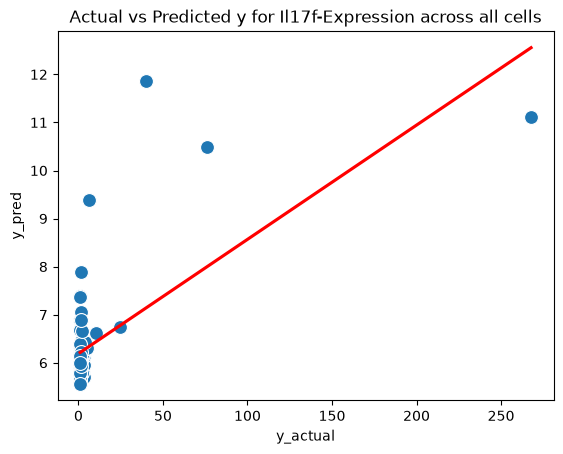

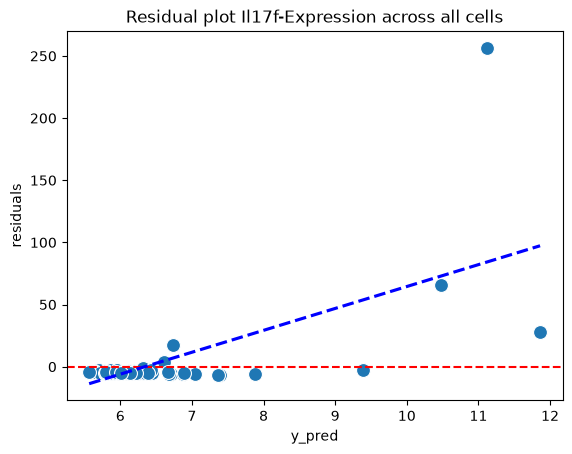

-4.201839850210726


In [6]:
def r2_gen(gen_name, plot=True, plot_residues = True):
    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    ATAC_seq_Gene = ATACseq_reg[ATACseq_reg["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATACseq_reg["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    #für Vergleich von Y
    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    ci=None, line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted y for {gen_name}-Expression across all cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()
        
    return  r2, cv, ridge


r2_Il17f, cv, ridge_Il17f= r2_gen("Il17f", plot=True, plot_residues=True)
print(cv)


### 2.4.2: Regressionsmodell - GD T Zellen

In [7]:
RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

ATAC_gd_path = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_seq_gd_TSS = pd.read_csv(ATAC_gd_path)

ATACseq_gd_reg = ATAC_seq_gd_TSS[ATAC_seq_gd_TSS["TSS"].isnull()]


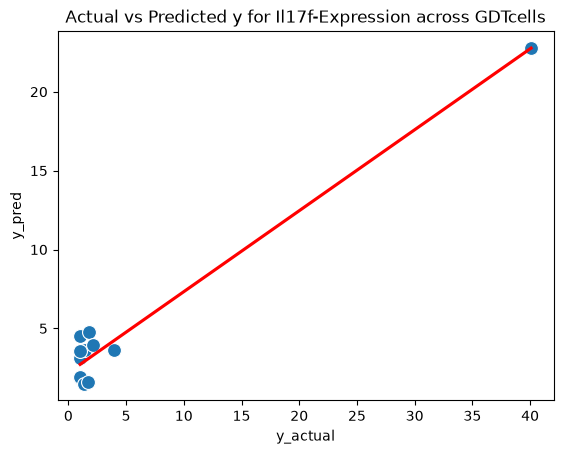

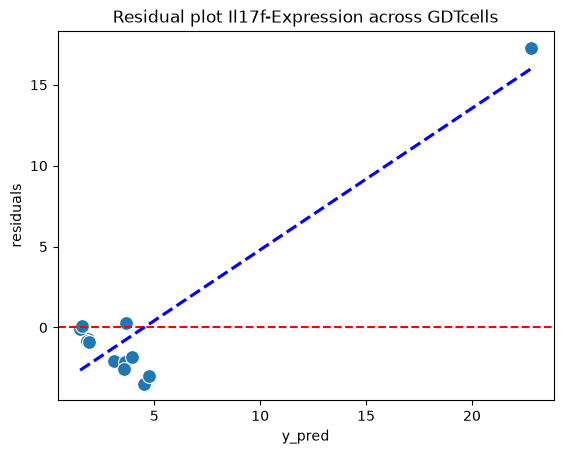

0.7525420449833191

In [8]:
def r2_gen_gd(gen_name, plot=True, plot_residues = True):
    #Y_RNA
    RNA_seq_Gene = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    ATAC_seq_Gene = ATACseq_gd_reg[ATACseq_gd_reg["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATACseq_gd_reg["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    #für Vergleich von Y
    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    ci=None, line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted y for {gen_name}-Expression across GDTcells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across GDTcells")
        plt.show()
        
    return  r2, cv, ridge


r2_Il17f, cv, ridge= r2_gen_gd("Il17f", plot=True, plot_residues=True)
r2_Il17f


### 2.4.3: Funktion für relevante Gene

In [9]:
for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, ridge= r2_gen(gen_name, plot=False, plot_residues=False)
    print(f"{gen_name}_all: R²={r2:.3f}, CV={cv:.3f}")

for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, ridge= r2_gen_gd(gen_name, plot=False, plot_residues=False)
    print(f"{gen_name}_gd: R²={r2:.3f}, CV={cv:.3f}")

Il17f_all: R²=0.046, CV=-4.202
Rorc_all: R²=0.901, CV=0.668
Sox13_all: R²=0.445, CV=-214.382
Gzma_all: R²=0.985, CV=0.908
Eomes_all: R²=0.985, CV=0.925
Actb_all: R²=0.631, CV=0.172
Il17f_gd: R²=0.753, CV=-36.095
Rorc_gd: R²=0.992, CV=-8251.986
Sox13_gd: R²=0.993, CV=-22.483
Gzma_gd: R²=0.984, CV=-7.616
Eomes_gd: R²=0.988, CV=-37097.790
Actb_gd: R²=0.750, CV=-1.313


Rorc, Gzma und Eomes zeigen hohe Gini-Scores in γδ-T-Zellen und können gleichzeitig durch die chromatin accessibility ihrer CREs über alle Immunzelltypen hinweg stabil vorhergesagt werden (hohes R², positives CV).

### 2.4.4: Activating vs. repressing CREs based on sign of reg. coef.

Can confirm, that Genes are primarily regulated through activating CREs.  

To-Do: Is there a way to present the findings nicely?

In [10]:
#build_gene_peak_dict(ATAC_seq)

def build_gene_peak_dict(ATAC_seq):

    gene_to_peaks = {}

    ATAC_filtered = ATAC_seq[ATAC_seq["genes.within.100Kb"].notna()]

    for index, row in ATAC_filtered.iterrows():

        peak_ID = row["ImmGenATAC1219.peakID"]

        for gene in str(row["genes.within.100Kb"]).split(","):
            
            gene = gene.strip()

            if gene not in gene_to_peaks:
                gene_to_peaks[gene] = []
            
            gene_to_peaks[gene].append(peak_ID)

    return gene_to_peaks

gene_peak_dictionary = build_gene_peak_dict(ATAC_data_removed)

In [11]:
#r2_gen_TSS - ridge function w/ Promotor

ATACseq_reg_TSS = ATAC_data_removed.copy()

def r2_gen_TSS(gen_name, plot=True, plot_residues = True):
    #Y_RNA
    RNA_seq_Gene = RNAseq_reg[RNAseq_reg["Unnamed: 0"] == gen_name]
    y = RNA_seq_Gene.drop("Unnamed: 0", axis=1, errors="ignore").T

    #X_ATAC
    peak_ids = gene_peak_dictionary.get(gen_name, [])
    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["ImmGenATAC1219.peakID"].isin(peak_ids)]

    ##ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    ##peak_ids = ATACseq_reg_TSS["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_Gene.drop(annotation_cols, axis=1, errors="ignore").T
    
    #Index angleichen
    common_cells = X.index.intersection(y.index)
    X = X.loc[common_cells]
    y = y.loc[common_cells]

    #Standardscale and choosing best alpha
    X_scaled = StandardScaler().fit_transform(X)
    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # CV mit bestem alpha
    cv = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
        X, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    #für Vergleich von Y
    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    ci=None, line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted y for {gen_name}-Expression across all cells inkl. TSS")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells inkl. TSS")
        plt.show()
        
    return  r2, cv, ridge


for gen_name in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, ridge= r2_gen_TSS(gen_name, plot=False, plot_residues=False)
    print(f"{gen_name}_all: R²={r2:.3f}, CV={cv:.3f}")

Il17f_all: R²=0.054, CV=-4.165
Rorc_all: R²=0.905, CV=0.659
Sox13_all: R²=0.450, CV=-203.209
Gzma_all: R²=0.986, CV=0.899
Eomes_all: R²=0.986, CV=0.928
Actb_all: R²=0.633, CV=0.163


In [12]:
#Coefficient Dataframe

def coef_gen(gen_name):
    r2, cv, ridge = r2_gen_TSS(gen_name, plot=False, plot_residues=False) #Falls Error: Anpassen welche Ridge Funktion benutzt wird!

    ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]
    peak_ids = ATAC_seq_Gene["ImmGenATAC1219.peakID"].values

    coef_df = pd.DataFrame({"peakID": peak_ids, "coefficient": ridge.coef_})

    #eine Spalte soll direkt Vorzeicehn interpretieren
    coef_df["sign"] = coef_df["coefficient"].apply(lambda x: "+" if x > 0 else "-")

    # Effektstärke
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs().round(1)

    #inaktiv# Sortieren aktiv und repressvi
    #coef_df["sign_order"] = coef_df["sign"].map({"repressing": 0,"activating": 1})

    # zuerst repressing/activating, dann nach Stärke
    coef_df = coef_df.sort_values(by=["abs_coefficient"], ascending=[False])

    #inaktiv# Hilfsspalte wieder entfernen
    ##coef_df = coef_df.drop(columns="sign_order")

    return coef_df, r2, cv, peak_ids

coef_Gzma, r2, cv, peak_ids = coef_gen("Gzma")
coef_Gzma["abs_coefficient"].describe()
coef_Gzma

,peakID,coefficient,sign,abs_coefficient
26,ImmGenATAC1219.peak_142098,715.915569,+,715.9
21,ImmGenATAC1219.peak_142093,486.993120,+,487.0
53,ImmGenATAC1219.peak_142129,412.479079,+,412.5
40,ImmGenATAC1219.peak_142114,409.974730,+,410.0
22,ImmGenATAC1219.peak_142094,-393.385473,-,393.4
...,...,...,...,...
46,ImmGenATAC1219.peak_142120,-8.826416,-,8.8
67,ImmGenATAC1219.peak_142147,8.322973,+,8.3
55,ImmGenATAC1219.peak_142133,-7.726329,-,7.7
64,ImmGenATAC1219.peak_142144,-2.435170,-,2.4


In [13]:
#comparing strongest 10 CREs of all three 
coef_Rorc, r2, cv = coef_gen("Rorc")
coef_Gzma, r2, cv = coef_gen("Gzma")
coef_Cd44, r2, cv = coef_gen("Cd44")
coef_Cd46, r2, cv = coef_gen("Cd46")


vergleich = pd.concat(
    [
        coef_Rorc[["peakID", "abs_coefficient", "sign"]].head(10),
        coef_Gzma[["peakID", "abs_coefficient", "sign"]].head(10),
        coef_Eomes[["peakID", "abs_coefficient", "sign"]].head(10),
        coef_IL17f[["peakID", "abs_coefficient", "sign"]].head(10),
    ],
    axis=1,
    keys=["Rorc", "Gzma", "Eomes", "IL17f"]
)

repression_percent = (coef_Rorc.loc[coef_Rorc["coefficient"] < 0,"abs_coefficient"].sum()
                                  /coef_Rorc["abs_coefficient"].sum()) * 100

print(repression_percent)

topk_has_repressor = (coef_Rorc.sort_values("abs_coefficient", ascending=False).head(10)["coefficient"] < 0).any()

print(topk_has_repressor)

vergleich

coef_Cd46


ValueError: too many values to unpack (expected 3)

### !! 2.4.5: Creating a dataframe w/ just repressive regulated genes

In [13]:
#verschiedene RNA_seq Datensätze für den Scan
RNA_seq_housekeeper = RNA_seq[(RNA_seq["Unnamed: 0"] == "Eomes") | (RNA_seq["Unnamed: 0"] == "Gzma") | (RNA_seq["Unnamed: 0"] == "Rorc")]

numeric_cols = RNA_seq.select_dtypes(include=[np.number]).columns
noise_frac = (RNA_seq[numeric_cols] < 1.5).sum(axis=1) / len(numeric_cols)
genes_keep = noise_frac[noise_frac < 0.7].index

RNA_seq_filtered = RNA_seq[noise_frac < 0.7]

RNA_seq_random420 = RNA_seq_filtered.sample(n=420, random_state=0)

In [14]:
#3hr runtime!
#function that checks which Genes are regulated primarely by repressive CREs


def find_repressive_genes(RNAseq, rep_threshold = 50, topk_threshold = 10):

    results = []

    genes = RNAseq["Unnamed: 0"].unique()

    for gene in genes:
        try:
            coef_df, r2, cv = coef_gen(gene)

            #Repressionsanteil
            total_effect = coef_df["abs_coefficient"].sum()

            if total_effect == 0:
                continue
            
            repression_percent = (coef_df.loc[coef_df["coefficient"] < 0,"abs_coefficient"].sum()
                                  /total_effect) * 100
            
            #Ist unter den Top-k mindestens ein Repressor?
            topk_has_repressor = (coef_df.sort_values("abs_coefficient", ascending=False).head(topk_threshold)["coefficient"] < 0).any()

            #Criterions erfüllt?
            if (repression_percent >= rep_threshold and topk_has_repressor):
                
                strongest_repressor = (coef_df[coef_df["coefficient"] < 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                strongest_activator = (coef_df[coef_df["coefficient"] > 0].sort_values("abs_coefficient", ascending=False).iloc[0])

                results.append({
                    "gene": gene,
                    "repression_percent": round(repression_percent,1),

                    "strongest_repressor_peakID": strongest_repressor["peakID"],
                    "strongest_repressor_coef": strongest_repressor["coefficient"],

                    "strongest_activator_peakID": strongest_activator["peakID"],
                    "strongest_activator_coef": strongest_activator["coefficient"],

                    "r2": round(r2, 2),
                    "cv": round(cv, 2),

                    "cv_category":
                        "Sehr Gut" if cv > 0.85 else
                        "Okay" if cv > 0.59 else
                        "wenigstens im positiven" if cv > 0 else
                        "negativ :(",
                })
                        
        except Exception:
            continue
        
    return pd.DataFrame(results)


givamialista = find_repressive_genes(RNA_seq, rep_threshold = 50, topk_threshold = 10)
givamialista.to_csv("data/repressive_regulated_genes.csv",index=False)

KeyboardInterrupt: 

### 2.4.5: Analyzing the repressive CRE in more detail

In [ ]:
#extracting that big summaofabitch 

repressive_genes_Path = Path('data') / 'repressive_regulated_genes.csv'
repressive_regulated_genes = pd.read_csv(repressive_genes_Path)

repressive_regulated_genes

NameError: name 'Path' is not defined

In [ ]:
#keeping only interesting genes
#those who have a highCV (working regression modell) or are genes relevant for our lineage

gene_list_path = Path('data') / 'specific_genes_group.csv'
gene_list_all = pd.read_csv(gene_list_path)

gene_list = (pd.concat([gene_list_all["abT"],gene_list_all["gdT"]]).dropna().drop_duplicates())

repressive_regulated_genes["cv_category"].unique()
repressive_genes_OkayCV = repressive_regulated_genes[(repressive_regulated_genes["cv_category"] == "Okay") |
                                                     (repressive_regulated_genes["cv_category"] == "wenigstens im positiven") |
                                                     (repressive_regulated_genes["gene"].isin(gene_list))]

print(len(repressive_genes_OkayCV))
repressive_genes_OkayCV



1693


,gene,repression_percent,strongest_repressor_peakID,strongest_repressor_coef,strongest_activator_peakID,strongest_activator_coef,r2,cv,cv_category
1,0610011F06Rik,56.9,ImmGenATAC1219.peak_209824,-2.881565,ImmGenATAC1219.peak_209836,5.451082,0.65,0.26,wenigstens im positiven
3,1110001J03Rik,65.3,ImmGenATAC1219.peak_395222,-1.491283,ImmGenATAC1219.peak_395224,1.543214,0.25,0.04,wenigstens im positiven
4,1110002L01Rik,52.9,ImmGenATAC1219.peak_95993,-0.675317,ImmGenATAC1219.peak_95972,0.521662,0.51,0.23,wenigstens im positiven
5,1110004E09Rik,61.0,ImmGenATAC1219.peak_201797,-0.762059,ImmGenATAC1219.peak_201775,0.745871,0.26,0.18,wenigstens im positiven
8,1110038B12Rik,57.4,ImmGenATAC1219.peak_213410,-6.400597,ImmGenATAC1219.peak_213476,4.161269,0.61,0.20,wenigstens im positiven
...,...,...,...,...,...,...,...,...,...
2513,Zswim1,53.0,ImmGenATAC1219.peak_293257,-2.443430,ImmGenATAC1219.peak_293319,3.251412,0.60,0.17,wenigstens im positiven
2515,Zyx,51.1,ImmGenATAC1219.peak_396243,-56.537202,ImmGenATAC1219.peak_396288,91.492683,0.86,0.69,Okay
2516,Zzef1,69.6,ImmGenATAC1219.peak_80923,-18.128822,ImmGenATAC1219.peak_80932,10.603551,0.31,0.15,wenigstens im positiven
2517,Zzz3,50.0,ImmGenATAC1219.peak_325555,-6.107843,ImmGenATAC1219.peak_325538,6.100798,0.51,0.04,wenigstens im positiven


In [ ]:
cv_order = {"wenigstens im positiven": 1,"Okay": 0}

repressive_genes_OkayCV = (repressive_genes_OkayCV.assign(cv_rank=repressive_genes_OkayCV["cv_category"].map(cv_order))
    .sort_values(by=["cv_rank", "repression_percent"],ascending=[True, False]).drop(columns="cv_rank"))

repressive_genes_OkayCV

,gene,repression_percent,strongest_repressor_peakID,strongest_repressor_coef,strongest_activator_peakID,strongest_activator_coef,r2,cv,cv_category
2347,Vprbp,61.1,ImmGenATAC1219.peak_496615,-18.636580,ImmGenATAC1219.peak_496600,14.323978,0.81,0.62,Okay
2412,Zfhx2,60.4,ImmGenATAC1219.peak_153110,-1.434884,ImmGenATAC1219.peak_153126,2.858096,0.81,0.68,Okay
702,Eif4b,57.5,ImmGenATAC1219.peak_185158,-82.415141,ImmGenATAC1219.peak_185111,98.146671,0.94,0.61,Okay
397,Cd27,57.1,ImmGenATAC1219.peak_413873,-51.113023,ImmGenATAC1219.peak_413900,33.874526,0.88,0.66,Okay
1921,Shisa5,57.0,ImmGenATAC1219.peak_497274,-154.444672,ImmGenATAC1219.peak_497310,246.948845,0.80,0.69,Okay
...,...,...,...,...,...,...,...,...,...
2081,Taf15,50.0,ImmGenATAC1219.peak_84176,-1.052976,ImmGenATAC1219.peak_84175,1.102893,0.65,0.27,wenigstens im positiven
2281,Uba7,50.0,ImmGenATAC1219.peak_496904,-35.994485,ImmGenATAC1219.peak_496941,29.164547,0.57,0.17,wenigstens im positiven
2324,Usp3,50.0,ImmGenATAC1219.peak_488262,-19.337974,ImmGenATAC1219.peak_488269,33.385886,0.57,0.31,wenigstens im positiven
2371,Wdr61,50.0,ImmGenATAC1219.peak_484542,-8.170568,ImmGenATAC1219.peak_484559,13.759864,0.46,0.07,wenigstens im positiven


--> CD27 as a primarely repressive regulated gene!

## 2.4.Poster:

### 1) Creating dictionaries

In [24]:
display(coef_df.head())
print(coef_df.columns)


,peakID,coefficient,sign,abs_coefficient
0,ImmGenATAC1219.peak_2700,-0.003976,-,0.0
1,ImmGenATAC1219.peak_2701,-0.004213,-,0.0
2,ImmGenATAC1219.peak_2702,-0.002853,-,0.0
3,ImmGenATAC1219.peak_2703,0.003842,+,0.0
4,ImmGenATAC1219.peak_2704,-0.000444,-,0.0


Index(['peakID', 'coefficient', 'sign', 'abs_coefficient'], dtype='str')


In [27]:
#dictionary with all genes listed and their respective peaks within 100kb
gene_peak_dictionary

gene_peak_dictionary_100 = dict(list(gene_peak_dictionary.items())[:100])


#dictionary with all genes listed and the abs_coef of all their peaks

gene_coef_dictionary = {}

for gen_name in gene_peak_dictionary.keys():
    try:
        coef_df, r2, cv, peak_ids = coef_gen(gen_name)
        
        peak_coef_dict = dict(zip(coef_df["peakID"],coef_df["coefficient"]))

        gene_coef_dictionary[gen_name] = {
                "cv": cv,
                "r2": r2,
                "coefs": peak_coef_dict}
    
    except Exception as e:
        gene_coef_dictionary[gen_name] = {
                "cv": None,
                "r2": None,
                "coefs": {},
                "error": str(e)
            }

gene_coef_dictionary.to_csv("data/gene_coef_dictionary.csv", index=False)
gene_coef_dictionary


C:\Users\peter\AppData\Local\Temp\ipykernel_7880\2616991476.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ATAC_seq_Gene = ATACseq_reg_TSS[ATACseq_reg_TSS["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]


AttributeError: 'dict' object has no attribute 'to_csv'

In [30]:
gene_coef_df = pd.DataFrame.from_dict(
    gene_coef_dictionary,
    orient="index"
).reset_index()

gene_coef_df = gene_coef_df.rename(
    columns={"index": "gene"}
)

display(gene_coef_df)

gene_coef_df.to_csv("data/gene_coef_dictionary.csv", index=False)



,gene,cv,r2,coefs,error
0,Xkr4,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
1,Rp1,-1.122908,0.887571,"{'ImmGenATAC1219.peak_48': 1.7791684818132834,...",NaN
2,Sox17,-427.130314,0.572920,"{'ImmGenATAC1219.peak_82': 4.527048421275342, ...",NaN
3,Mrpl15,0.167903,0.387567,"{'ImmGenATAC1219.peak_119': 12.27785531993507,...",NaN
4,Lypla1,-0.060274,0.073396,"{'ImmGenATAC1219.peak_125': 2.048810672896512,...",NaN
...,...,...,...,...,...
23422,Ddx3y,0.335150,0.536000,{'ImmGenATAC1219.peak_512533': 28.995622794885...,NaN
23423,Rbmy,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
23424,Gm21708,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...
23425,Gm3376,NaN,NaN,{},\nAll the 25 fits failed.\nIt is very likely t...


### 2) Doing the Thing 

## ChatGPT Plots:

### 2.4.6: Repressive Promotors?

### 2.4.7: Location of repressive CREs relative to activating CREs

In [18]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'

Gene_annotations = pd.read_csv(gene_annotations_path, sep="\t", names=cols)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def plot_cre_location(gen_name, bin_width=10_000, min_abs_coef=None):
    """
    Gewichtetes Histogramm der Regressions-CREs relativ zum TSS.

    Blau = repressiv (Ridge-Koeffizient < 0)
    Rot  = aktivierend (Ridge-Koeffizient > 0)

    Die Balkenhöhe ist die Summe der absoluten Ridge-Koeffizienten
    innerhalb jedes 10-kb-Bins, nicht nur die Anzahl der Peaks.
    """

    # 1. Alle Peaks und Ridge-Koeffizienten aus dem Regressionsmodell
    coef_df, r2, cv, _ = coef_gen(gen_name)

    coef_df = coef_df.copy()
    coef_df["peakID"] = coef_df["peakID"].astype(str)
    coef_df = coef_df.drop_duplicates(subset="peakID")

    # 2. TSS strangkorrekt bestimmen
    Gene_annotations["TSS_pos"] = Gene_annotations.apply(
        lambda row: row["txStart"] if row["strand"] == "+" else row["txEnd"],
        axis=1
    )

    # TSS-Position des untersuchten Gens auswählen
    tss_df = (
        Gene_annotations.loc[
            Gene_annotations["gene_name"].eq(gen_name),
            ["gene_name", "TSS_pos"]
        ]
        .drop_duplicates(subset="gene_name")
        .copy()
    )

    if tss_df.empty:
        raise ValueError(f"Kein TSS für {gen_name} in Gene_annotations gefunden.")

    # 3. Summit-Positionen aller ATAC-Peaks holen
    peak_position_df = (
        ATACseq_gd_reg[
            ["ImmGenATAC1219.peakID", "Summit"]
        ]
        .copy()
        .rename(columns={"ImmGenATAC1219.peakID": "peakID"})
    )

    peak_position_df["peakID"] = peak_position_df["peakID"].astype(str)

    # 4. Peaks aus dem Regressionsmodell mit Position und TSS verbinden
    plot_df = (
        coef_df
        .merge(peak_position_df, on="peakID", how="inner")
        .merge(tss_df, how="cross")
    )

    # 5. Genomische Distanz vom Peak-Summit zum TSS
    plot_df["distance"] = plot_df["Summit"] - plot_df["TSS_pos"]

    # Nur Peaks innerhalb des verwendeten ±100-kb-Fensters
    plot_df = plot_df[plot_df["distance"].abs() <= 100_000].copy()

    # Optional: sehr schwache Koeffizienten ausschließen
    if min_abs_coef is not None:
        plot_df = plot_df[
            plot_df["coefficient"].abs() >= min_abs_coef
        ].copy()

    # Koeffizienten von exakt 0 ausschließen
    plot_df = plot_df[plot_df["coefficient"] != 0].copy()

    if plot_df.empty:
        raise ValueError(f"Für {gen_name} wurden keine Peaks zum Plotten gefunden.")

    # 6. Positiv = aktivierend, negativ = repressiv
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    # Effektstärke: ungerundeter absoluter Ridge-Koeffizient
    plot_df["abs_coef_raw"] = plot_df["coefficient"].abs()

    # 7. 10-kb-Bins über ±100 kb
    bins = np.arange(-100_000, 100_000 + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Gewichtete Summe der Koeffizienten je Bin
    activating_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "activating", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "repressive", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    # 8. Plot
    fig, ax = plt.subplots(figsize=(11, 5.5))

    bar_width = bin_width * 0.42

    ax.bar(
        bin_centers - bar_width / 2,
        repressive_strength,
        width=bar_width,
        color="#1f77b4",
        edgecolor="black",
        linewidth=0.3,
        label="Repressive CREs (β < 0)"
    )

    ax.bar(
        bin_centers + bar_width / 2,
        activating_strength,
        width=bar_width,
        color="#d62728",
        edgecolor="black",
        linewidth=0.3,
        label="Activating CREs (β > 0)"
    )

    # TSS bei Distanz 0 markieren
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="TSS"
    )

    ax.set_title(
        f"Location and effect strength of repressive vs activating CREs: {gen_name}"
    )
    ax.set_xlabel("Distance to TSS (kb)")
    ax.set_ylabel("Sum of absolute Ridge coefficients")
    ax.set_xlim(-100_000, 100_000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1000:.0f}")
    )

    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Gene: {gen_name}")
    print(f"R²: {r2:.3f}")
    print(f"CV: {cv}")
    print("\nNumber of peaks:")
    print(
        plot_df["effect"]
        .value_counts()
        .reindex(["repressive", "activating"], fill_value=0)
    )

    return plot_df, fig, ax

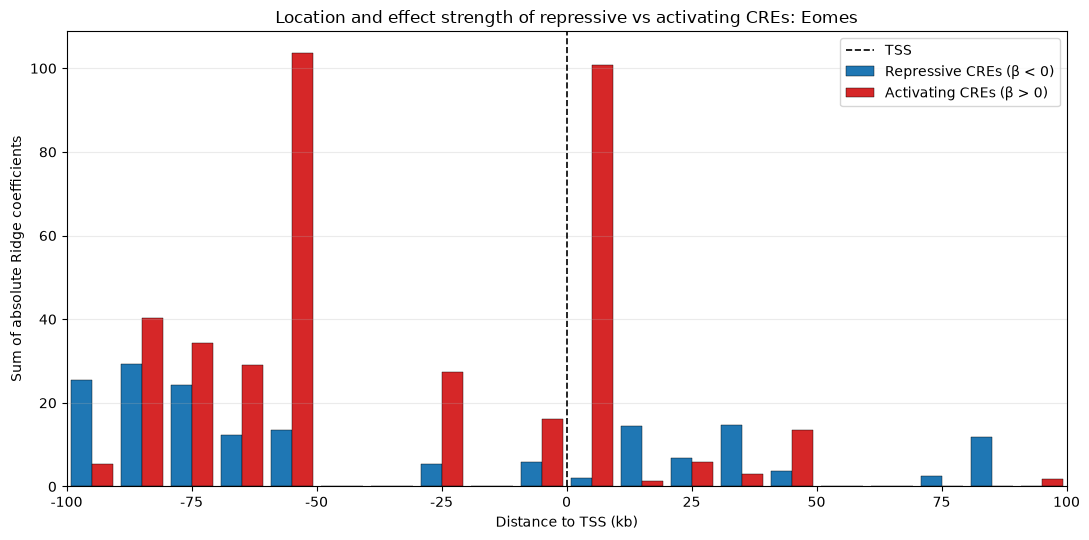

Gene: Eomes
R²: 0.986
CV: 0.9277633173458287

Number of peaks:
effect
repressive    27
activating    33
Name: count, dtype: int64


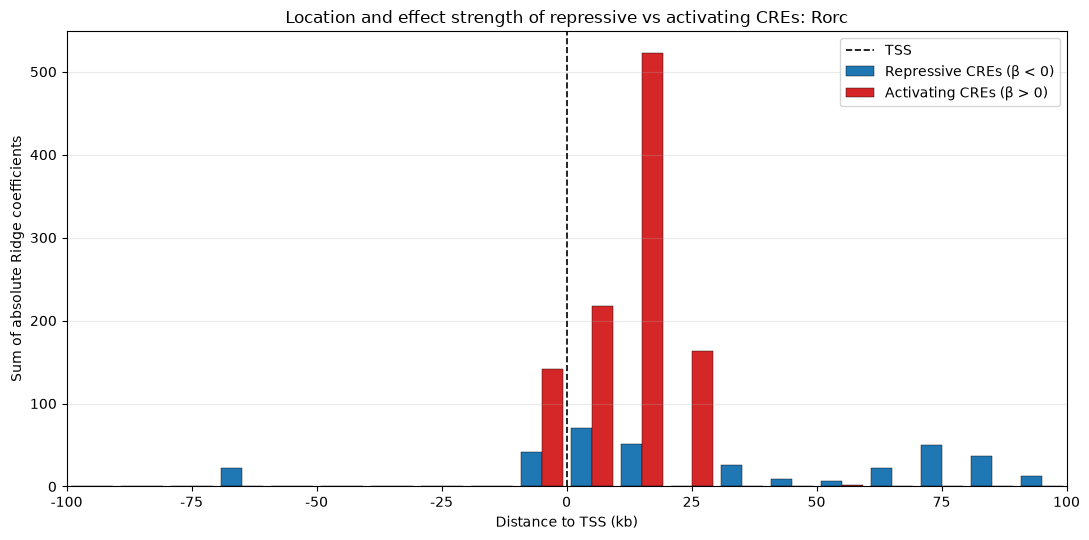

Gene: Rorc
R²: 0.905
CV: 0.6588147802771551

Number of peaks:
effect
repressive    25
activating    21
Name: count, dtype: int64


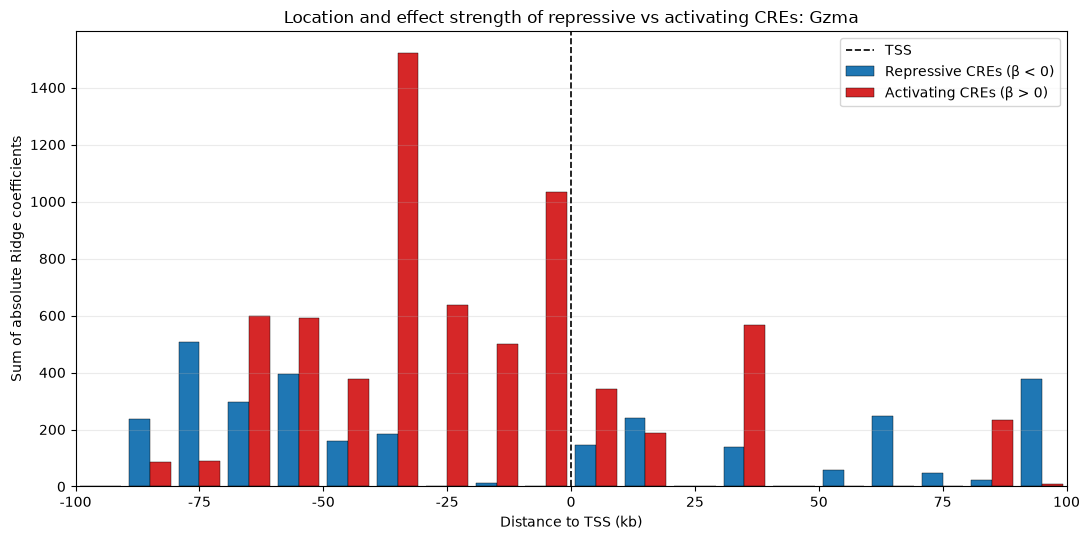

Gene: Gzma
R²: 0.986
CV: 0.8988520809298424

Number of peaks:
effect
repressive    29
activating    33
Name: count, dtype: int64


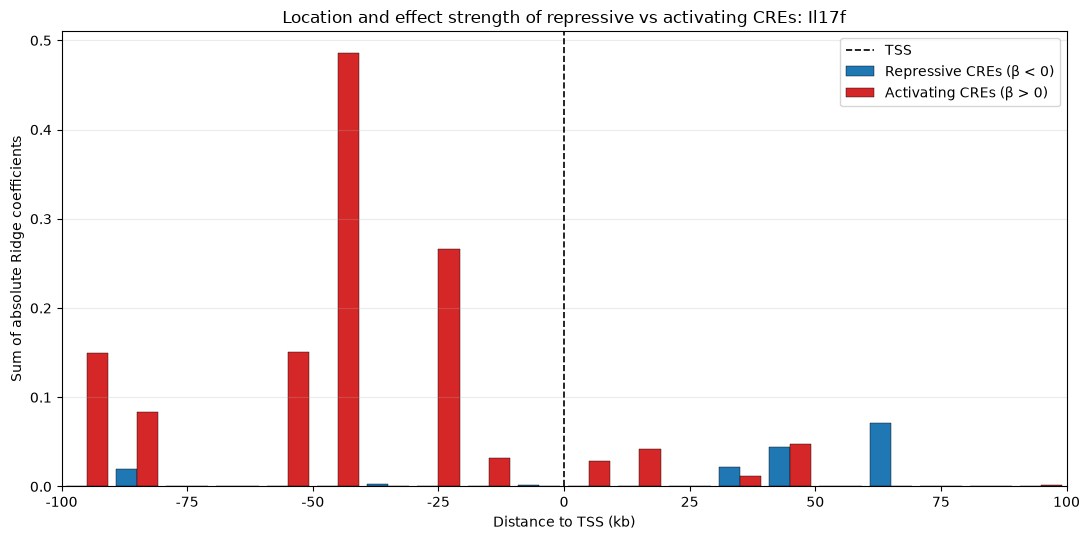

Gene: Il17f
R²: 0.054
CV: -4.164615646432379

Number of peaks:
effect
repressive    11
activating    17
Name: count, dtype: int64


In [20]:
eomes_location_df, fig, ax = plot_cre_location("Eomes")
rorc_location_df, fig, ax = plot_cre_location("Rorc")
gzma_location_df, fig, ax = plot_cre_location("Gzma")
Il17f_location_df, fig, ax = plot_cre_location("Il17f")

#display(eomes_location_df.sort_values("distance")[["peakID", "distance", "coefficient", "effect"]])

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def highlight_peak_in_location_plot(
    location_df,
    peak_id,
    gen_name="Il17f",
    bin_width=10_000
):
    """
    Zeichnet den CRE-Location-Plot und hebt einen bestimmten Peak hervor.

    Parameters
    ----------
    location_df : DataFrame
        Zum Beispiel Il17f_location_df aus plot_cre_location().
        Muss mindestens peakID, distance und coefficient enthalten.

    peak_id : str
        Die Peak-ID, die hervorgehoben werden soll.

    gen_name : str
        Name für den Plot-Titel.

    bin_width : int
        Breite der genomischen Bins in bp, Standard = 10 kb.
    """

    plt.rcParams.update({
        "font.family": "Tahoma",
        "font.size": 10
    })

    # Kopie erstellen, damit das ursprüngliche DataFrame nicht verändert wird
    plot_df = location_df.copy()
    plot_df["peakID"] = plot_df["peakID"].astype(str)

    # Prüfen, ob die benötigten Spalten existieren
    required_columns = {"peakID", "distance", "coefficient"}

    if not required_columns.issubset(plot_df.columns):
        raise ValueError(
            "location_df benötigt mindestens die Spalten: "
            "'peakID', 'distance' und 'coefficient'."
        )

    # Nur Peaks im ±100-kb-Fenster und mit echtem Effekt behalten
    plot_df = plot_df[
        (plot_df["distance"].abs() <= 100_000)
        & (plot_df["coefficient"] != 0)
    ].copy()

    # Aktivierend oder repressiv aus dem Ridge-Koeffizienten bestimmen
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    # Ungerundete Effektstärke für die gewichteten Balken
    plot_df["abs_coef_raw"] = plot_df["coefficient"].abs()

    # Eingegebene Peak-ID suchen
    highlighted_peak = plot_df[
        plot_df["peakID"].eq(str(peak_id))
    ].copy()

    if highlighted_peak.empty:
        raise ValueError(
            f"Peak-ID '{peak_id}' wurde nicht in {gen_name}_location_df gefunden."
        )

    # Falls es ausnahmsweise mehrere Zeilen mit derselben Peak-ID gibt
    highlighted_peak = highlighted_peak.iloc[0]

    # Bins und Bin-Mittelpunkte definieren
    bins = np.arange(-100_000, 100_000 + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Gewichtete Summen der absoluten Koeffizienten pro Bin
    activating_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "activating", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive_strength, _ = np.histogram(
        plot_df.loc[plot_df["effect"] == "repressive", "distance"],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    # Passenden Bin des hervorgehobenen Peaks bestimmen
    peak_distance = highlighted_peak["distance"]

    peak_bin_index = np.searchsorted(
        bins,
        peak_distance,
        side="right"
    ) - 1

    # Sonderfall: Peak liegt exakt auf der letzten Grenze bei +100 kb
    peak_bin_index = min(
        max(peak_bin_index, 0),
        len(bin_centers) - 1
    )

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(11, 5.5))

    bar_width = bin_width * 0.42

    ax.bar(
        bin_centers - bar_width / 2,
        repressive_strength,
        width=bar_width,
        color="#4C78A8",
        edgecolor="black",
        linewidth=0.3,
        label="Repressive CREs (β < 0)"
    )

    ax.bar(
        bin_centers + bar_width / 2,
        activating_strength,
        width=bar_width,
        color="#C94C4C",
        edgecolor="black",
        linewidth=0.3,
        label="Activating CREs (β > 0)"
    )

    # TSS markieren
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="TSS"
    )

    # Prüfen, ob der Peak in einem aktivierenden oder repressiven Balken liegt
    if highlighted_peak["effect"] == "activating":
        peak_bar_height = activating_strength[peak_bin_index]
    else:
        peak_bar_height = repressive_strength[peak_bin_index]

    # Exakte Peak-Position markieren
    ax.axvline(
        peak_distance,
        color="#F4C542",
        linestyle=":",
        linewidth=2,
        zorder=4
    )

    # Stern oberhalb des zugehörigen Balkens
    ax.scatter(
        peak_distance,
        peak_bar_height,
        s=220,
        marker="*",
        color="#F4C542",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
        label="Highlighted peak"
    )

    # Annotation mit Peak-ID, Distanz und Koeffizient
    ax.annotate(
        (
            f"{highlighted_peak['peakID']}\n"
            f"distance = {peak_distance / 1000:.1f} kb\n"
            f"β = {highlighted_peak['coefficient']:.3f}"
        ),
        xy=(peak_distance, peak_bar_height),
        xytext=(0, 28),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        arrowprops={
            "arrowstyle": "-",
            "color": "black",
            "linewidth": 0.8
        }
    )

    ax.set_title(
        f"Location and effect strength of CREs: {gen_name}"
    )
    ax.set_xlabel("Distance to TSS (kb)")
    ax.set_ylabel("Sum of absolute Ridge coefficients")
    ax.set_xlim(-100_000, 100_000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1000:.0f}")
    )

    max_height = max(
        activating_strength.max(),
        repressive_strength.max()
    )

    ax.set_ylim(0, max_height * 1.25)

    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(
        highlighted_peak[
            ["peakID", "distance", "coefficient", "effect", "abs_coef_raw"]
        ].to_frame().T
    )

    return highlighted_peak, fig, ax

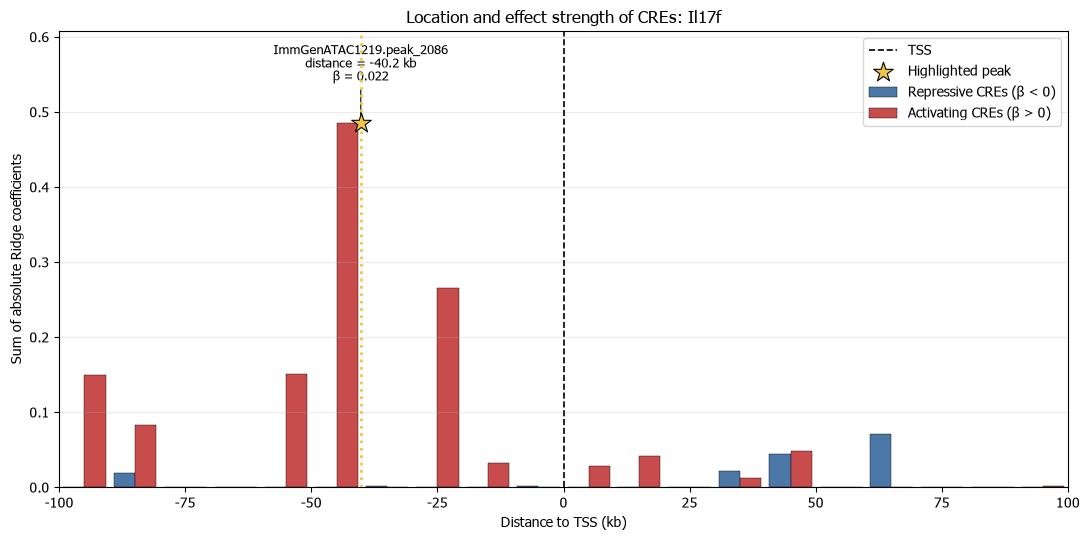

,peakID,distance,coefficient,effect,abs_coef_raw
10,ImmGenATAC1219.peak_2086,-40200,0.021907,activating,0.021907


In [22]:
special_peak, fig, ax = highlight_peak_in_location_plot(
    Il17f_location_df,
    peak_id="ImmGenATAC1219.peak_2086",
    gen_name="Il17f")

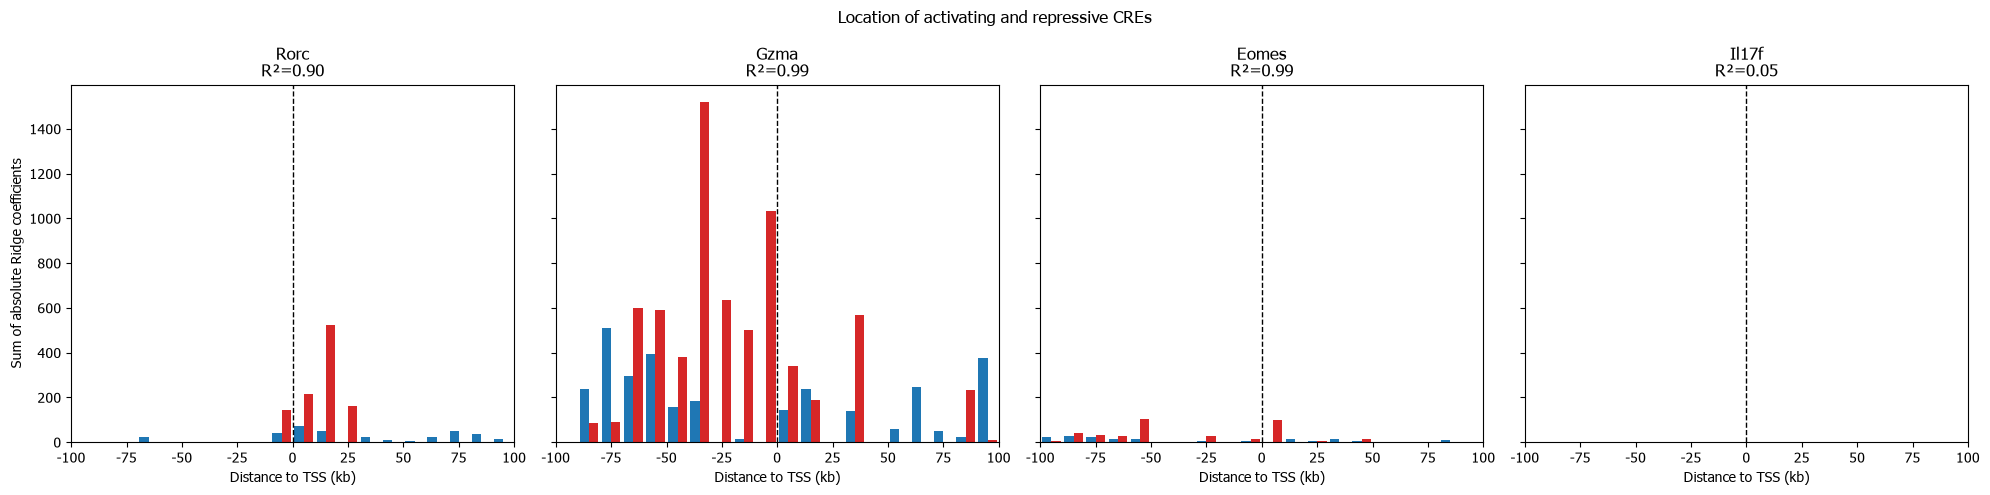

In [23]:
genes = ["Rorc", "Gzma", "Eomes", "Il17f"]

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5),
    sharey=True
)

for gen_name, ax in zip(genes, axes):

    # Daten für dieses Gen holen
    coef_df, r2, cv, _ = coef_gen(gen_name)

    coef_df = coef_df.copy()
    coef_df["peakID"] = coef_df["peakID"].astype(str)
    coef_df = coef_df.drop_duplicates(subset="peakID")

    # TSS
    tss_df = (
        Gene_annotations.loc[
            Gene_annotations["gene_name"] == gen_name,
            ["gene_name", "TSS_pos"]
        ]
        .drop_duplicates("gene_name")
    )

    # Peakpositionen
    peak_position_df = (
        ATACseq_gd_reg[
            ["ImmGenATAC1219.peakID", "Summit"]
        ]
        .rename(columns={"ImmGenATAC1219.peakID": "peakID"})
        .copy()
    )

    peak_position_df["peakID"] = peak_position_df["peakID"].astype(str)

    # Mergen
    plot_df = (
        coef_df
        .merge(peak_position_df, on="peakID")
        .merge(tss_df, how="cross")
    )

    # Distanz
    plot_df["distance"] = (
        plot_df["Summit"] - plot_df["TSS_pos"]
    )

    plot_df = plot_df[
        (plot_df["distance"].abs() <= 100000)
        & (plot_df["coefficient"] != 0)
    ].copy()

    # aktivierend/repressiv
    plot_df["effect"] = np.where(
        plot_df["coefficient"] > 0,
        "activating",
        "repressive"
    )

    plot_df["abs_coef_raw"] = (
        plot_df["coefficient"].abs()
    )

    # Histogramme
    bins = np.arange(-100000, 100001, 10000)
    centers = (bins[:-1] + bins[1:]) / 2

    activating, _ = np.histogram(
        plot_df.loc[
            plot_df["effect"] == "activating",
            "distance"
        ],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "activating",
            "abs_coef_raw"
        ]
    )

    repressive, _ = np.histogram(
        plot_df.loc[
            plot_df["effect"] == "repressive",
            "distance"
        ],
        bins=bins,
        weights=plot_df.loc[
            plot_df["effect"] == "repressive",
            "abs_coef_raw"
        ]
    )

    width = 10000 * 0.42

    ax.bar(
        centers - width/2,
        repressive,
        width=width,
        color="#1f77b4"
    )

    ax.bar(
        centers + width/2,
        activating,
        width=width,
        color="#d62728"
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{gen_name}\nR²={r2:.2f}"
    )

    ax.set_xlim(-100000, 100000)

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{int(x/1000)}"
        )
    )

axes[0].set_ylabel(
    "Sum of absolute Ridge coefficients"
)

for ax in axes:
    ax.set_xlabel("Distance to TSS (kb)")

plt.suptitle(
    "Location of activating and repressive CREs"
)

plt.tight_layout()
plt.show()

### 2.4.8: Are there CREs that repress one but activate another
- Do i check the whole Dataset, only those with Good CV or only our three genes?
- How can I plot this nicely? Check Yoshida maybe?
    - statistics might be viable -> 20% of genes are repressive controlled, strongest repressor is that gene, X% of GD-Tcells are repressive yada yada

### 2.4.9: CRE profile of a gene

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_cre_profiles(genes, strong_threshold=0.1):
    """
    Erstellt einen gestapelten Balken pro Gen.

    Kategorien:
    - repressive: coefficient < 0
    - weak activating: 0 < coefficient < strong_threshold
    - strong activating: coefficient >= strong_threshold
    """

    # Erlaubt sowohl einen einzelnen Gen-Namen als auch eine Liste von Genen
    if isinstance(genes, str):
        genes = [genes]

    # Einheitliche Schrift für den Plot
    plt.rcParams.update({
        "font.family": "Tahoma",
        "font.size": 10
    })

    categories = ["repressive", "weak activating", "strong activating"]

    # Zwei ähnliche Rottöne für schwach/stark aktivierende CREs
    colors = {
        "repressive": "#4C78A8",        # blau
        "weak activating": "#F2A0A0",   # hellrot
        "strong activating": "#C94C4C"  # dunkelrot
    }

    all_summaries = []
    model_info = []

    for gen_name in genes:

        # Ridge-Koeffizienten für das jeweilige Gen holen
        coef_df, r2, cv, _ = coef_gen(gen_name)

        coef_df = coef_df.copy()
        coef_df["peakID"] = coef_df["peakID"].astype(str)

        # Sicherheit: doppelte Peak-IDs nur einmal zählen
        coef_df = coef_df.drop_duplicates(subset="peakID")

        # Peaks ohne Effekt ausschließen
        coef_df = coef_df[coef_df["coefficient"] != 0].copy()

        # Kategorie anhand von Richtung und Stärke festlegen
        coef_df["cre_class"] = np.select(
            [
                coef_df["coefficient"] < 0,

                (coef_df["coefficient"] > 0)
                & (coef_df["coefficient"] < strong_threshold),

                coef_df["coefficient"] >= strong_threshold
            ],
            [
                "repressive",
                "weak activating",
                "strong activating"
            ],
            default="other"
        )

        # Anzahl der CREs je Kategorie zählen
        gene_summary = (
            coef_df["cre_class"]
            .value_counts()
            .reindex(categories, fill_value=0)
            .rename_axis("cre_class")
            .reset_index(name="count")
        )

        gene_summary["gene"] = gen_name
        all_summaries.append(gene_summary)

        model_info.append({
            "gene": gen_name,
            "R2": r2,
            "CV": cv
        })

    # Alle Gen-Zusammenfassungen in einem DataFrame kombinieren
    summary_df = pd.concat(all_summaries, ignore_index=True)
    model_info_df = pd.DataFrame(model_info)

    # Plot vorbereiten
    fig, ax = plt.subplots(figsize=(1.8 * len(genes) + 3, 6))

    x_positions = np.arange(len(genes))
    bottom = np.zeros(len(genes))

    # Jede CRE-Kategorie als eigener gestapelter Abschnitt
    for category in categories:

        counts = (
            summary_df[summary_df["cre_class"] == category]
            .set_index("gene")
            .reindex(genes)["count"]
            .to_numpy()
        )

        bars = ax.bar(
            x_positions,
            counts,
            bottom=bottom,
            color=colors[category],
            edgecolor="black",
            linewidth=0.5,
            label=category
        )

        # Anzahl direkt in die jeweiligen Balkensegmente schreiben
        for x, count, current_bottom in zip(x_positions, counts, bottom):
            if count > 0:
                ax.text(
                    x,
                    current_bottom + count / 2,
                    str(int(count)),
                    ha="center",
                    va="center"
                )

        bottom += counts

    ax.set_xticks(x_positions)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Number of CREs")
    ax.set_title("CRE profiles based on Ridge regression coefficients")
    ax.legend(title="CRE category", frameon=True)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(summary_df.pivot(
        index="gene",
        columns="cre_class",
        values="count"
    ).reindex(columns=categories, fill_value=0))

    display(model_info_df)

    return summary_df, model_info_df, fig, ax

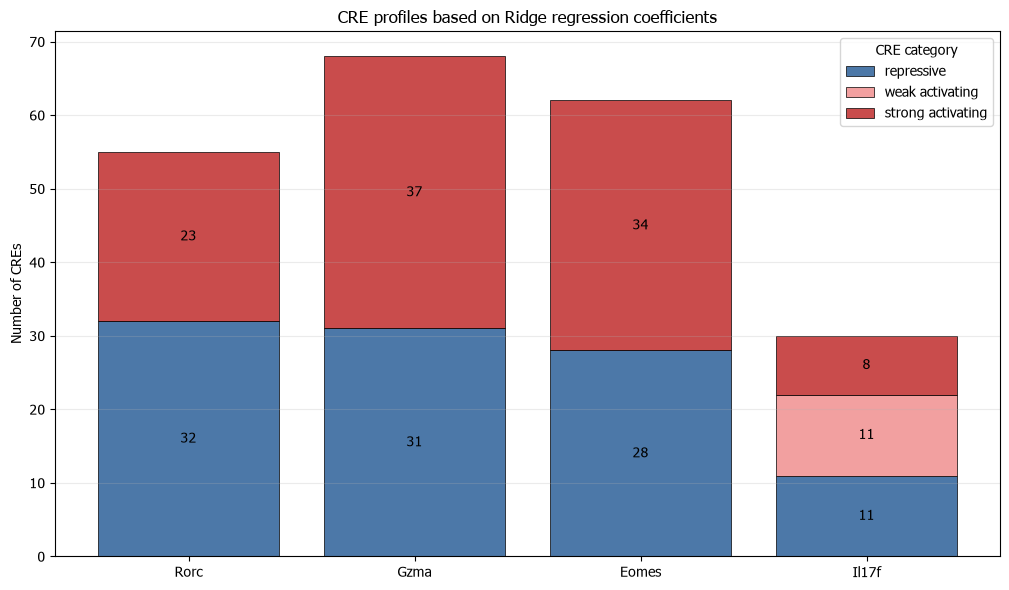

cre_class,repressive,weak activating,strong activating
gene,,,
Eomes,28,0,34
Gzma,31,0,37
Il17f,11,11,8
Rorc,32,0,23


,gene,R2,CV
0,Rorc,0.904932,0.658815
1,Gzma,0.985775,0.898852
2,Eomes,0.985806,0.927763
3,Il17f,0.054160,-4.164616


In [47]:
genes = ["Rorc", "Gzma", "Eomes", "Il17f"]

cre_summary, model_info, fig, ax = plot_cre_profiles(
    genes,
    strong_threshold=0.1
)

### 2.4.10: Genome Track

# Playground

### Creating a Gene -> peakID dictionary using results_corr_all.csv

In [ ]:
gene_peak_df = pd.DataFrame([(gene, peak)
     for gene, peaks in gene_peak_dictionary.items()
     for peak in peaks],columns=["gene", "peakID"])

gene_peak_df.to_csv('data/gene_peak_dictionary.csv', index=False) 